In [1]:
# FORESIGHT - Exploratory Data Analysis
# Demand & Inventory Intelligence

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("FORESIGHT EDA Notebook")
print("Libraries loaded successfully")

FORESIGHT EDA Notebook
Libraries loaded successfully


In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
RAW_DATA_DIR = BASE_DIR / "data" / "raw"

sales = pd.read_csv(RAW_DATA_DIR / "sales_daily.csv")
sku_master = pd.read_csv(RAW_DATA_DIR / "sku_master.csv")
calendar = pd.read_csv(RAW_DATA_DIR / "calendar.csv")
inventory = pd.read_csv(RAW_DATA_DIR / "inventory_snapshots.csv")

print("Datasets loaded successfully")
print("Sales:", sales.shape)
print("SKU Master:", sku_master.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)

Datasets loaded successfully
Sales: (36550, 6)
SKU Master: (50, 8)
Calendar: (731, 11)
Inventory: (4800, 8)


In [3]:
print("SALES DATA")
display(sales.head())

print("\nSKU MASTER")
display(sku_master.head())

print("\nINVENTORY DATA")
display(inventory.head())

print("\nCALENDAR DATA")
display(calendar.head())


SALES DATA


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0



SKU MASTER


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU001,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,SKU003,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,SKU004,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,SKU005,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59



INVENTORY DATA


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22
3,2024-01-01,SKU004,34,4,7,5,12,42257.92
4,2024-01-01,SKU005,23,5,5,6,11,170945.89



CALENDAR DATA


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN
3,2024-01-04,2024,1,Q1,1,Thursday,0,Winter,NaN,0,NaN
4,2024-01-05,2024,1,Q1,1,Friday,0,Winter,NaN,0,NaN


In [4]:
print("DATA QUALITY CHECK")
print("-" * 40)

print("Sales missing values:", sales.isna().sum().sum())
print("SKU Master missing values:", sku_master.isna().sum().sum())
print("Inventory missing values:", inventory.isna().sum().sum())
print("Calendar missing values:", calendar.isna().sum().sum())

print("\nSales non-positive values:")
print("Units Sold:", (sales["Units_Sold"] <= 0).sum())
print("Revenue:", (sales["Revenue"] <= 0).sum())
print("Price:", (sales["Price"] <= 0).sum())

print("\nSKU Master:")
print("Negative Gross Margin:", (sku_master["Gross_Margin_Per_Unit"] < 0).sum())

print("\nInventory:")
print(
    "SKUs not present in master:",
    (~inventory["SKU"].isin(sku_master["SKU"])).sum()
)

DATA QUALITY CHECK
----------------------------------------
Sales missing values: 0
SKU Master missing values: 0
Inventory missing values: 0
Calendar missing values: 1379

Sales non-positive values:
Units Sold: 202
Revenue: 202
Price: 0

SKU Master:
Negative Gross Margin: 16

Inventory:
SKUs not present in master: 3600


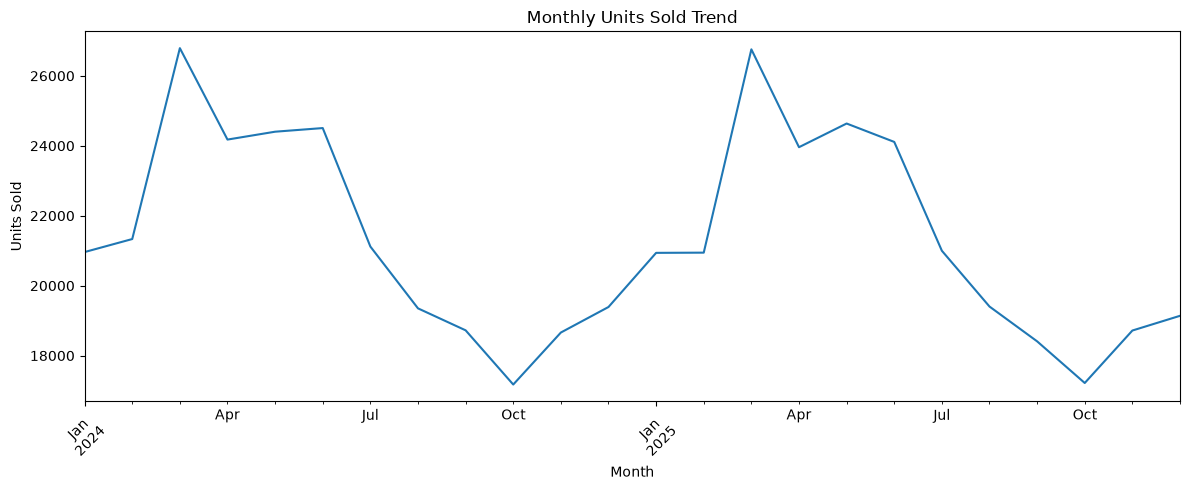

In [5]:
sales["Date"] = pd.to_datetime(sales["Date"])

monthly_sales = (
    sales.groupby(sales["Date"].dt.to_period("M"))["Units_Sold"]
    .sum()
)

plt.figure(figsize=(12, 5))
monthly_sales.plot()
plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Units Sold by Category:


Category
Home Decor    132570
Lighting      102431
Kitchen       101144
Storage        93367
Furniture      82298
Name: Units_Sold, dtype: int64

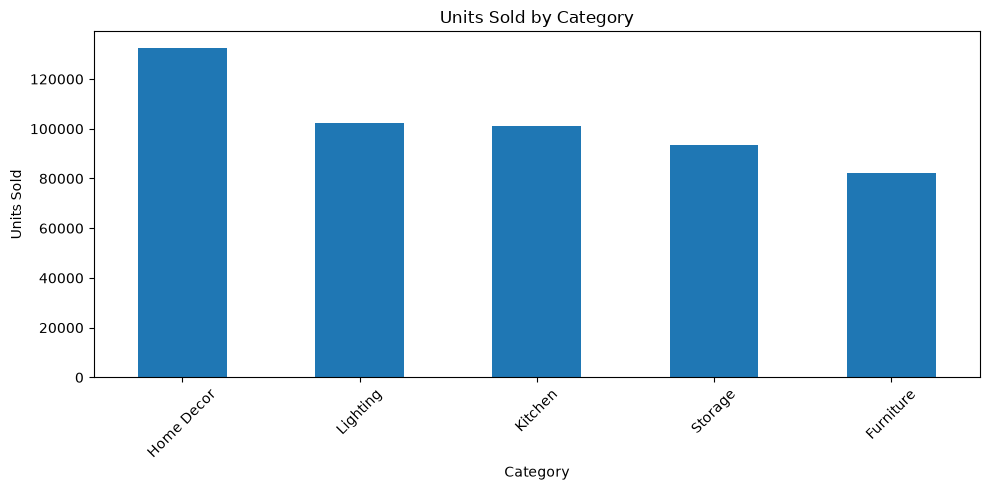

In [6]:
category_sales = (
    sales.merge(
        sku_master[["SKU", "Category"]],
        on="SKU",
        how="left"
    )
    .groupby("Category")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

print("Units Sold by Category:")
display(category_sales)

plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")
plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Inventory Summary:


,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
count,4800.00,4800.00,4800.00,4800.00,4800.00,4800.00
mean,304.14,213.09,8.44,83.15,211.75,1304166.47
std,280.89,244.46,3.49,70.26,179.91,1741551.24
min,2.00,0.00,3.00,5.00,10.00,2444.20
25%,109.00,49.00,5.00,35.00,87.00,252185.50
50%,229.00,135.00,8.00,67.00,169.00,683738.86
75%,418.00,292.00,11.25,112.00,286.00,1720023.44
max,2585.00,3060.00,14.00,746.00,1661.00,20279867.85


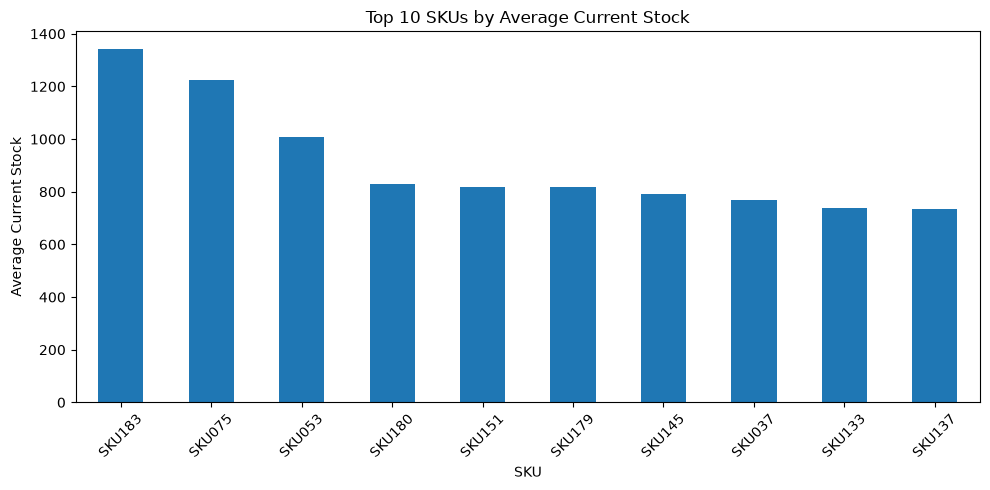

In [7]:
inventory_summary = inventory[
    ["Current_Stock", "On_Order", "Lead_Time_Days", "Safety_Stock", "Reorder_Point", "Inventory_Value"]
].describe().round(2)

print("Inventory Summary:")
display(inventory_summary)

plt.figure(figsize=(10, 5))
inventory.groupby("SKU")["Current_Stock"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 SKUs by Average Current Stock")
plt.xlabel("SKU")
plt.ylabel("Average Current Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


FORESIGHT Inventory Risk Distribution:


Risk
Markdown/Clear    18
Healthy           15
Reorder Now        9
Watch Volatile     8
Name: count, dtype: int64

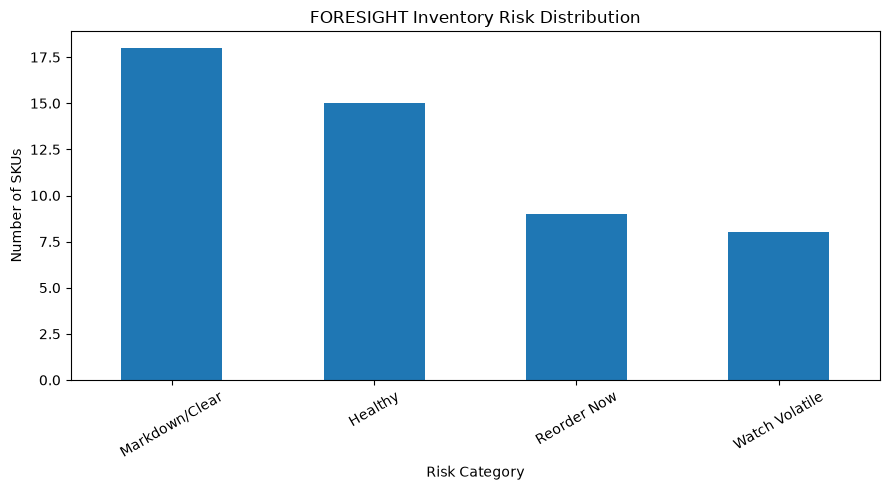

In [8]:
risk_file = BASE_DIR / "models" / "foresight_inventory_risk.csv"

risk = pd.read_csv(risk_file)

print("FORESIGHT Inventory Risk Distribution:")
risk_counts = risk["Risk"].value_counts()

display(risk_counts)

plt.figure(figsize=(9, 5))
risk_counts.plot(kind="bar")
plt.title("FORESIGHT Inventory Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of SKUs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Key EDA Observations

- The sales dataset contains 36,550 daily records covering 2024–2025.
- The SKU master contains 50 SKUs across the available product categories.
- Sales, SKU master, and inventory datasets contain no missing values.
- The calendar contains missing values only in optional `holiday` and `promotion_event` fields.
- 202 sales records contain non-positive Units Sold and Revenue values and should be treated as data-quality exceptions.
- 16 SKUs have negative Gross Margin Per Unit values and require business validation.
- The inventory dataset contains records for SKUs outside the current 50-SKU master scope.
- Monthly sales trends and category-level demand were examined to understand demand patterns.
- Inventory levels, reorder points, safety stock, and lead times were analyzed to support inventory-risk identification.
- The final FORESIGHT risk analysis categorizes SKUs into Reorder Now, Markdown/Clear, Watch Volatile, and Healthy.